# Information Coefficient (IC) Analysis — NSE Equity Futures Depth Signals

Measures predictive power of depth-book signals (A1–A6 + OBI) against forward mid-price returns across HDFCBANK, ICICIBANK, RELIANCE, TCS over ~16 trading days.

**Methodology:**
- Forward return horizon: 5, 10, 20, 50 packets
- IC metric: Spearman rank correlation (robust to outliers and non-linearity)
- IC computed per day × symbol pair, then aggregated

## Section 1 — Setup & Data Inventory

In [12]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import spearmanr

PROJECT_ROOT = Path("/Users/krishhiv/Desktop/argus-alpha-research")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from research.data.load_data import load_depth, DATA_ROOT
from research.features.depth_features import add_all_features

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"DATA_ROOT exists: {DATA_ROOT.exists()}")

DATA_ROOT: /Users/krishhiv/Desktop/argus-alpha-research/data/raw/depth
DATA_ROOT exists: True


In [13]:
# Discover all parquet files
all_parquets = sorted(DATA_ROOT.glob("trading_date=*/symbol=*/compacted-*.parquet"))
print(f"Total parquet files found: {len(all_parquets)}")

records = []
for p in all_parquets:
    # Extract date from trading_date=YYYY-MM-DD dir name
    date_str = p.parent.parent.name.split("=")[1]  # 'YYYY-MM-DD'
    # Extract symbol dir: symbol=UNDERLYING-MonthYear-FUT
    symbol_full = p.parent.name.split("=")[1]  # e.g. 'HDFCBANK-May2026-FUT'
    underlying = symbol_full.split("-")[0]     # e.g. 'HDFCBANK'
    # Skip BAJFINANCE
    if underlying.startswith("BAJFINANCE"):
        continue
    records.append({
        "date": date_str,
        "underlying": underlying,
        "symbol_name": symbol_full,
        "path": p,
    })

inventory = pd.DataFrame(records)
print(f"\nInventory shape: {inventory.shape}")
print("\nFiles per underlying:")
print(inventory.groupby("underlying")["date"].count().rename("days").to_frame())
print("\nAll trading dates:")
print(sorted(inventory["date"].unique()))

Total parquet files found: 64

Inventory shape: (64, 4)

Files per underlying:
            days
underlying      
HDFCBANK      16
ICICIBANK     16
RELIANCE      16
TCS           16

All trading dates:
['2026-04-24', '2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08', '2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18']


In [14]:
# --- Build previous-day calibration lookup ---
# For each file, compute median(bid_qty_01) using only that day's data.
# Then for each (underlying, date), store the PREVIOUS day's median
# as the calibration value. This is fully look-ahead free.

print("Computing calibration medians...")
calib = {}  # (underlying, date) -> median bid_qty_01

for _, row in inventory.iterrows():
    try:
        df_c = pd.read_parquet(row["path"], columns=["bid_qty_01"])
        calib[(row["underlying"], row["date"])] = float(df_c["bid_qty_01"].median())
    except Exception as e:
        print(f"  Calib error {row['underlying']} {row['date']}: {e}")

# Build prev_calib: (underlying, date) -> previous date's median (or None for first day)
prev_calib = {}
for underlying in inventory["underlying"].unique():
    dates = sorted(inventory[inventory["underlying"] == underlying]["date"].unique())
    for i, date in enumerate(dates):
        prev_calib[(underlying, date)] = calib.get((underlying, dates[i - 1])) if i > 0 else None

available = sum(1 for v in prev_calib.values() if v is not None)
print(f"Calibration ready: {len(calib)} files computed")
print(f"Previous-day lookup: {available}/{len(prev_calib)} pairs have a previous day")
print(f"First-day files (will be skipped): {len(prev_calib) - available}")

Computing calibration medians...
Calibration ready: 64 files computed
Previous-day lookup: 60/64 pairs have a previous day
First-day files (will be skipped): 4


## Section 2 — Feature Computation

In [ ]:
SIGNALS = [
    "obi",
    "a1_gradient_asymmetry",
    "a2_frag_bid", "a2_frag_ask",
    "a3_symmetry_break", "a3_symmetry_break_top", "a3_symmetry_break_deep",
    "a4_cog_divergence",
    "a5_condensation_signal",
    "a6_bid_shallowing", "a6_ask_shallowing",
]

HORIZONS = [5, 10, 20, 50]  # packets


def load_and_compute(path: Path, underlying: str, date: str, size_threshold: float, order_size: float):
    """Load one parquet file, compute features and forward returns.

    size_threshold and order_size must be passed explicitly from previous-day
    calibration — never computed from the current day's data.

    Returns None and prints a skip message for:
      - FileNotFoundError : parquet file missing from disk
      - ValueError        : file exists but has insufficient session rows (corrupt/incomplete)
      - Exception         : any other unexpected failure
    """
    try:
        df = load_depth(underlying, date, session_filter=True, path=path)
        df = add_all_features(df, size_threshold=size_threshold, order_size=order_size)

        for h in HORIZONS:
            df[f"fwd_ret_{h}"] = df["midprice"].shift(-h) / df["midprice"] - 1

        df["date"] = date
        df["underlying"] = underlying
        return df

    except FileNotFoundError:
        print(f"  SKIP {underlying} {date}: parquet file not found")
        return None
    except ValueError as e:
        print(f"  SKIP {underlying} {date}: {e}")
        return None
    except Exception as e:
        print(f"  ERROR {underlying} {date} (unexpected): {e}")
        return None

In [16]:
all_dfs = []
skipped = 0

for _, row in inventory.iterrows():
    key = (row["underlying"], row["date"])
    p_calib = prev_calib.get(key)

    if p_calib is None:
        print(f"  SKIP {row['underlying']} {row['date']}: first day, no previous-day calibration")
        skipped += 1
        continue

    size_threshold = p_calib           # previous day's median bid_qty_01
    order_size     = p_calib * 10      # previous day's median × 10

    df = load_and_compute(row["path"], row["underlying"], row["date"], size_threshold, order_size)
    if df is not None:
        print(f"  {row['underlying']} {row['date']} ... {len(df):,} rows  [thresh={size_threshold:.0f}, order_sz={order_size:.0f}]")
        all_dfs.append(df)

total_rows = sum(len(d) for d in all_dfs)
print(f"\nLoaded {len(all_dfs)} files ({skipped} skipped — first day per instrument)")
print(f"Total rows: {total_rows:,}")

  SKIP HDFCBANK 2026-04-24: first day, no previous-day calibration
  SKIP ICICIBANK 2026-04-24: first day, no previous-day calibration
  SKIP RELIANCE 2026-04-24: first day, no previous-day calibration
  SKIP TCS 2026-04-24: first day, no previous-day calibration
  HDFCBANK 2026-04-27 ... 92,996 rows  [thresh=1100, order_sz=11000]
  ICICIBANK 2026-04-27 ... 93,247 rows  [thresh=1400, order_sz=14000]
  RELIANCE 2026-04-27 ... 92,985 rows  [thresh=1000, order_sz=10000]
  TCS 2026-04-27 ... 91,942 rows  [thresh=175, order_sz=1750]
  HDFCBANK 2026-04-28 ... 91,761 rows  [thresh=1100, order_sz=11000]
  ICICIBANK 2026-04-28 ... 91,952 rows  [thresh=1400, order_sz=14000]
  RELIANCE 2026-04-28 ... 91,951 rows  [thresh=500, order_sz=5000]
  TCS 2026-04-28 ... 91,897 rows  [thresh=175, order_sz=1750]
  HDFCBANK 2026-04-29 ... 91,834 rows  [thresh=1100, order_sz=11000]
  ICICIBANK 2026-04-29 ... 91,642 rows  [thresh=700, order_sz=7000]
  RELIANCE 2026-04-29 ... 91,982 rows  [thresh=1000, order_sz

## Section 3 — IC Computation

Spearman rank correlation between each signal and each forward return horizon, computed per day × symbol pair.

In [17]:
ic_records = []

for df in all_dfs:
    date = df["date"].iloc[0]
    underlying = df["underlying"].iloc[0]

    for signal in SIGNALS:
        if signal not in df.columns:
            continue

        for h in HORIZONS:
            fwd_col = f"fwd_ret_{h}"
            if fwd_col not in df.columns:
                continue

            valid = df[[signal, fwd_col]].dropna()
            if len(valid) < 50:
                continue

            ic, pval = spearmanr(valid[signal], valid[fwd_col])

            ic_records.append({
                "date": date,
                "underlying": underlying,
                "signal": signal,
                "horizon": h,
                "ic": ic,
                "pval": pval,
                "n_obs": len(valid),
            })

ic_df = pd.DataFrame(ic_records)
print(f"IC DataFrame shape: {ic_df.shape}")
ic_df.head(10)

IC DataFrame shape: (2640, 7)


,date,underlying,signal,horizon,ic,pval,n_obs
0,2026-04-27,HDFCBANK,obi,5,0.023602,6.100581e-13,92991
1,2026-04-27,HDFCBANK,obi,10,0.033550,1.406299e-24,92986
2,2026-04-27,HDFCBANK,obi,20,0.038504,7.509718e-32,92976
3,2026-04-27,HDFCBANK,obi,50,0.031720,3.936814e-22,92946
4,2026-04-27,HDFCBANK,a1_gradient_asymmetry,5,-0.002491,4.475645e-01,92981
5,2026-04-27,HDFCBANK,a1_gradient_asymmetry,10,0.004472,1.726829e-01,92976
6,2026-04-27,HDFCBANK,a1_gradient_asymmetry,20,0.016260,7.118007e-07,92966
7,2026-04-27,HDFCBANK,a1_gradient_asymmetry,50,0.012501,1.383589e-04,92936
8,2026-04-27,HDFCBANK,a2_frag_bid,5,0.017125,1.765701e-07,92991
9,2026-04-27,HDFCBANK,a2_frag_bid,10,0.017245,1.448519e-07,92986


## Section 4 — IC Summary Table

The primary output: mean IC, IC IR, and directional consistency for each signal × horizon combination.

In [18]:
summary = (
    ic_df
    .groupby(["signal", "horizon"])["ic"]
    .agg(
        mean_ic="mean",
        std_ic="std",
        count="count",
    )
    .reset_index()
)

summary["icir"] = summary["mean_ic"] / (summary["std_ic"] + 1e-9)

# pct_positive: fraction of IC values > 0
pct_pos = (
    ic_df
    .groupby(["signal", "horizon"])["ic"]
    .apply(lambda x: (x > 0).mean())
    .reset_index()
    .rename(columns={"ic": "pct_positive"})
)
summary = summary.merge(pct_pos, on=["signal", "horizon"])

print("=" * 80)
print("IC SUMMARY TABLE — sorted by |mean_ic| within each horizon")
print("=" * 80)

for h in HORIZONS:
    sub = summary[summary["horizon"] == h].copy()
    sub = sub.sort_values("mean_ic", key=lambda s: s.abs(), ascending=False)
    sub = sub.reset_index(drop=True)

    print(f"\n--- Horizon = {h} packets ---")
    print(
        f"{'signal':<30} {'mean_ic':>9} {'std_ic':>9} {'icir':>9} "
        f"{'pct_pos':>9} {'n':>6}"
    )
    print("-" * 78)
    for _, r in sub.iterrows():
        print(
            f"{r['signal']:<30} {r['mean_ic']:>9.4f} {r['std_ic']:>9.4f} "
            f"{r['icir']:>9.4f} {r['pct_positive']:>9.4f} {int(r['count']):>6}"
        )

IC SUMMARY TABLE — sorted by |mean_ic| within each horizon

--- Horizon = 5 packets ---
signal                           mean_ic    std_ic      icir   pct_pos      n
------------------------------------------------------------------------------
a6_bid_shallowing                -0.0634    0.0196   -3.2280    0.0000     60
a6_ask_shallowing                 0.0558    0.0168    3.3135    1.0000     60
a5_condensation_signal            0.0505    0.0223    2.2684    0.9833     60
obi                               0.0196    0.0222    0.8852    0.7667     60
a2_frag_bid                       0.0155    0.0158    0.9805    0.8500     60
a3_symmetry_break                 0.0143    0.0121    1.1808    0.9000     60
a2_frag_ask                      -0.0071    0.0126   -0.5653    0.2833     60
a4_cog_divergence                -0.0065    0.0182   -0.3563    0.3500     60
a1_gradient_asymmetry            -0.0063    0.0114   -0.5539    0.3000     60
a3_symmetry_break_top             0.0045    0.0168   

## Section 5 — IC Heatmap

Mean IC across all symbols and days, by signal (rows) × horizon (columns).

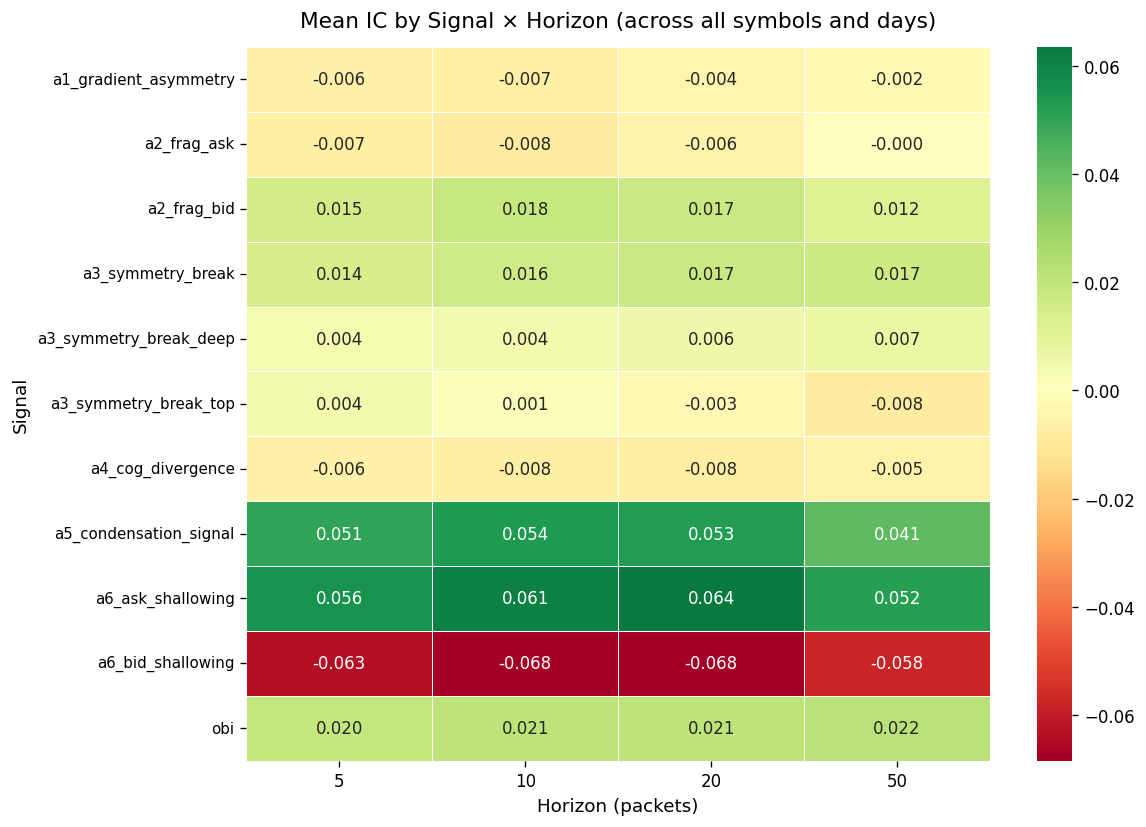

In [19]:
pivot = summary.pivot(index="signal", columns="horizon", values="mean_ic")

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
sns.heatmap(
    pivot,
    center=0,
    cmap="RdYlGn",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Mean IC by Signal × Horizon (across all symbols and days)", fontsize=13, pad=12)
ax.set_xlabel("Horizon (packets)", fontsize=11)
ax.set_ylabel("Signal", fontsize=11)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

## Section 6 — IC Time Series

Daily IC (averaged across symbols) over time for each signal, by horizon.

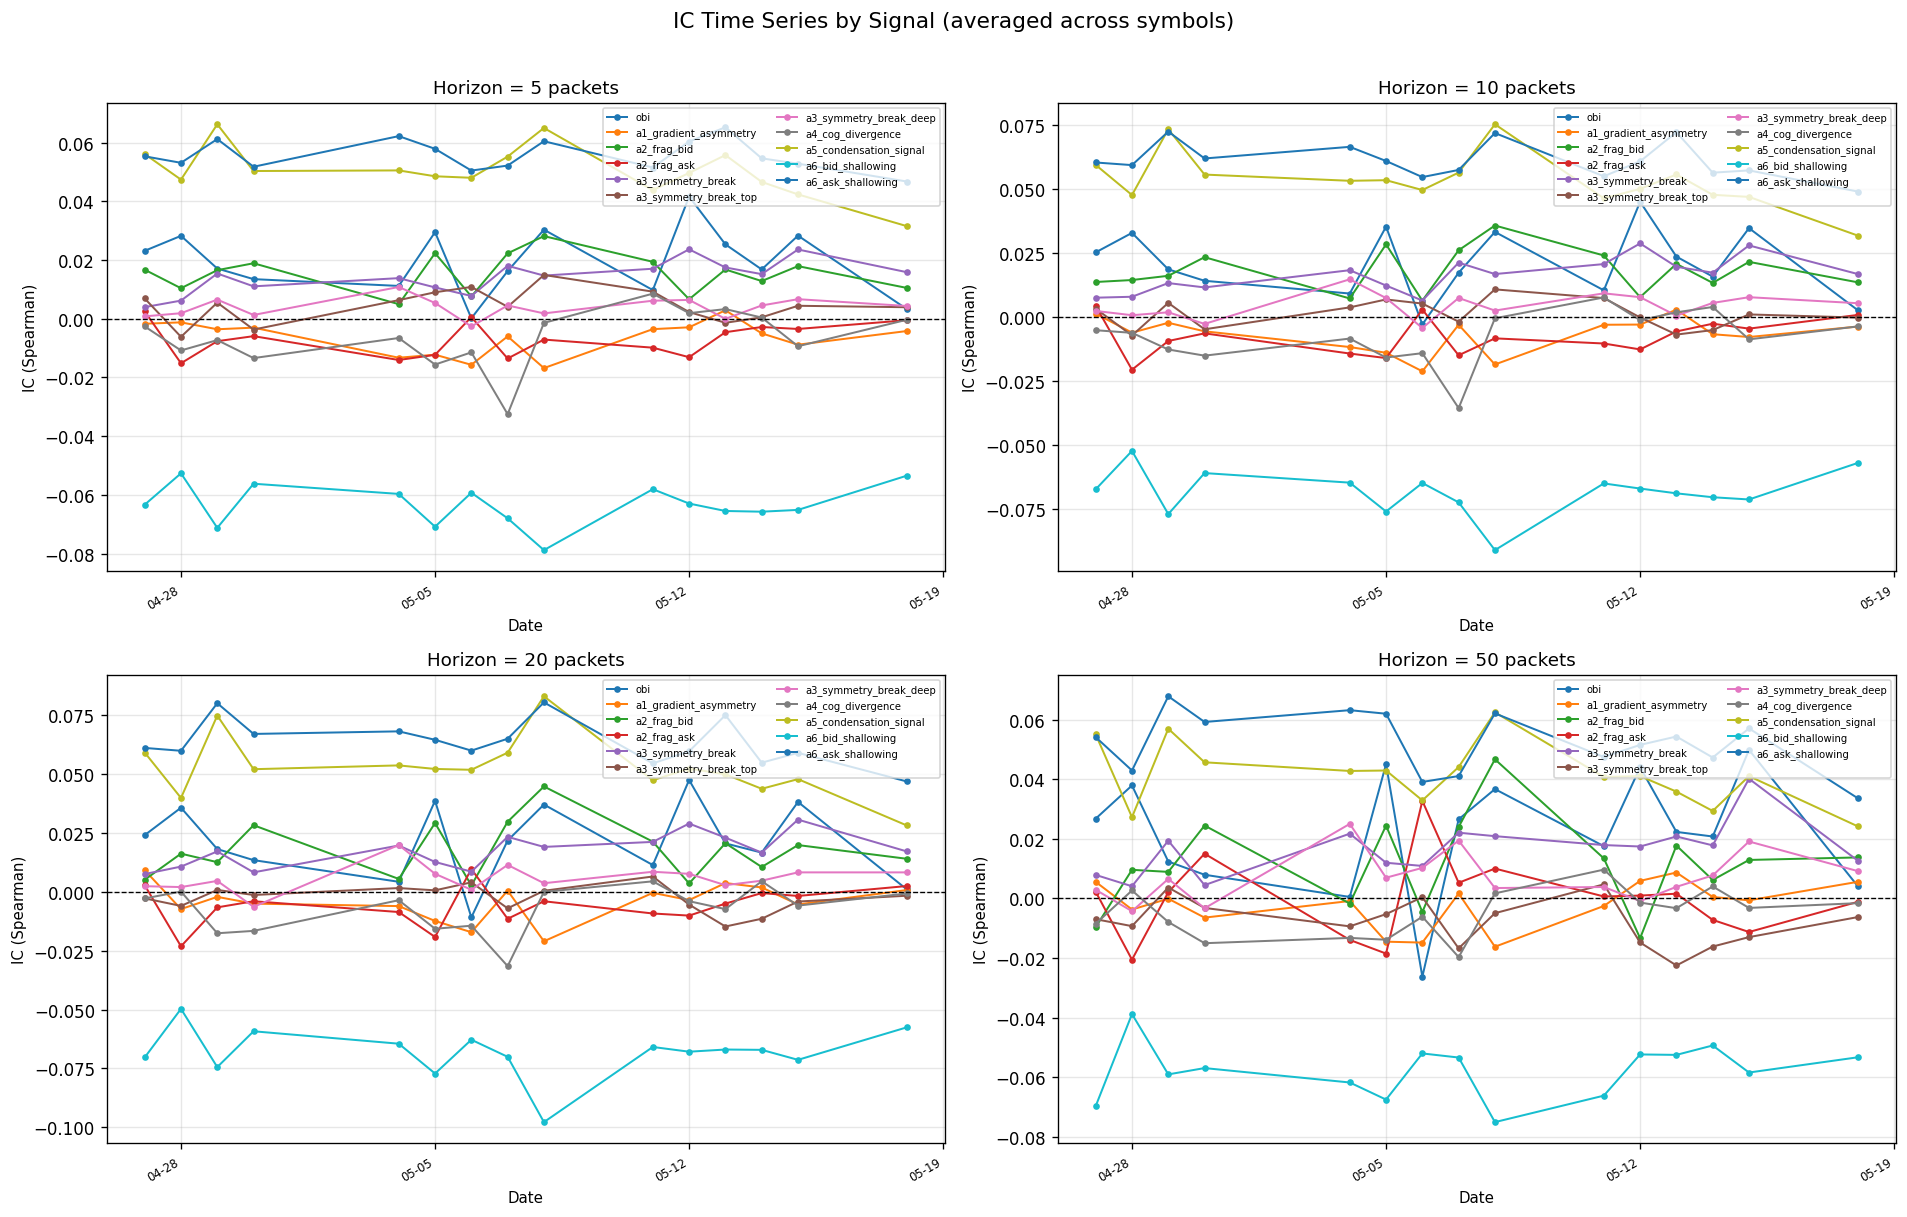

In [20]:
# Average IC across symbols per date × signal × horizon
ts_ic = (
    ic_df
    .groupby(["date", "signal", "horizon"])["ic"]
    .mean()
    .reset_index()
)
ts_ic["date_dt"] = pd.to_datetime(ts_ic["date"])
dates_sorted = sorted(ts_ic["date_dt"].unique())

fig, axes = plt.subplots(2, 2, figsize=(16, 10), dpi=120, sharey=False)
axes = axes.flatten()

for idx, h in enumerate(HORIZONS):
    ax = axes[idx]
    sub = ts_ic[ts_ic["horizon"] == h]

    for signal in SIGNALS:
        sig_data = sub[sub["signal"] == signal].sort_values("date_dt")
        if sig_data.empty:
            continue
        ax.plot(
            sig_data["date_dt"],
            sig_data["ic"],
            marker="o",
            markersize=3,
            linewidth=1.2,
            label=signal,
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Horizon = {h} packets", fontsize=11)
    ax.set_xlabel("Date", fontsize=9)
    ax.set_ylabel("IC (Spearman)", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6, ncol=2, loc="upper right")

fig.suptitle("IC Time Series by Signal (averaged across symbols)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Section 7 — Per-Symbol IC Breakdown

Mean IC at horizon=10 packets, broken down by underlying symbol.

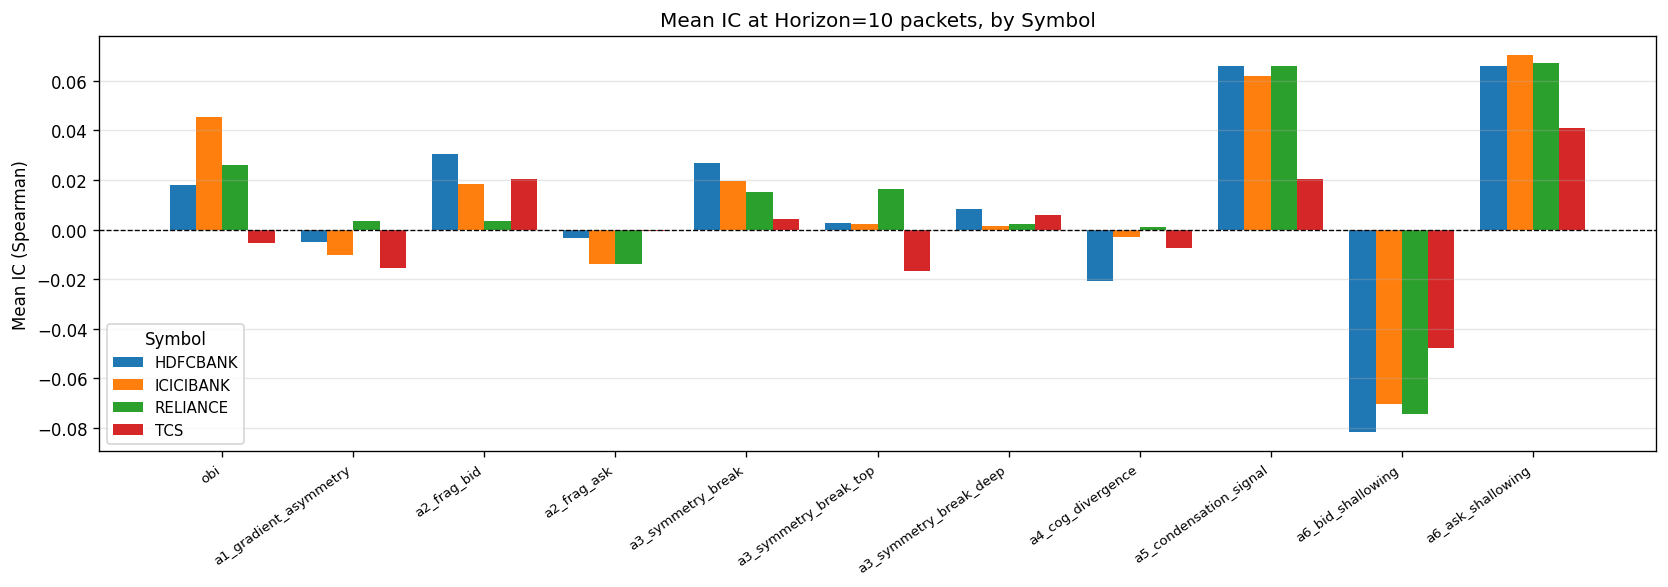

In [21]:
h10 = ic_df[ic_df["horizon"] == 10]
by_sym = (
    h10
    .groupby(["signal", "underlying"])["ic"]
    .mean()
    .reset_index()
)

symbols = sorted(by_sym["underlying"].unique())
n_signals = len(SIGNALS)
x = np.arange(n_signals)
width = 0.2

fig, ax = plt.subplots(figsize=(14, 5), dpi=120)

for i, sym in enumerate(symbols):
    vals = [
        by_sym.loc[(by_sym["signal"] == sig) & (by_sym["underlying"] == sym), "ic"]
        .values[0]
        if len(by_sym.loc[(by_sym["signal"] == sig) & (by_sym["underlying"] == sym), "ic"]) > 0
        else np.nan
        for sig in SIGNALS
    ]
    offset = (i - len(symbols) / 2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=sym)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(SIGNALS, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Mean IC (Spearman)", fontsize=10)
ax.set_title("Mean IC at Horizon=10 packets, by Symbol", fontsize=12)
ax.legend(title="Symbol", fontsize=9)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Section 8 — Time-of-Day IC

Morning (hour < 12 IST) vs afternoon (hour >= 12 IST) IC at horizon=10 packets.

In [22]:
# Recompute IC split by morning / afternoon using ts_ist hour
tod_records = []

for df in all_dfs:
    date = df["date"].iloc[0]
    underlying = df["underlying"].iloc[0]

    # ts_ist is tz-naive IST after load_depth
    hour = df["ts_ist"].dt.hour
    for session_name, mask in [("morning", hour < 12), ("afternoon", hour >= 12)]:
        sub = df[mask]
        if len(sub) < 50:
            continue

        for signal in SIGNALS:
            if signal not in sub.columns:
                continue

            fwd_col = "fwd_ret_10"
            if fwd_col not in sub.columns:
                continue

            valid = sub[[signal, fwd_col]].dropna()
            if len(valid) < 50:
                continue

            ic, pval = spearmanr(valid[signal], valid[fwd_col])
            tod_records.append({
                "date": date,
                "underlying": underlying,
                "signal": signal,
                "session": session_name,
                "ic": ic,
                "n_obs": len(valid),
            })

tod_df = pd.DataFrame(tod_records)
print(f"Time-of-day IC records: {len(tod_df)}")

tod_summary = (
    tod_df
    .groupby(["signal", "session"])["ic"]
    .mean()
    .reset_index()
)

Time-of-day IC records: 1320


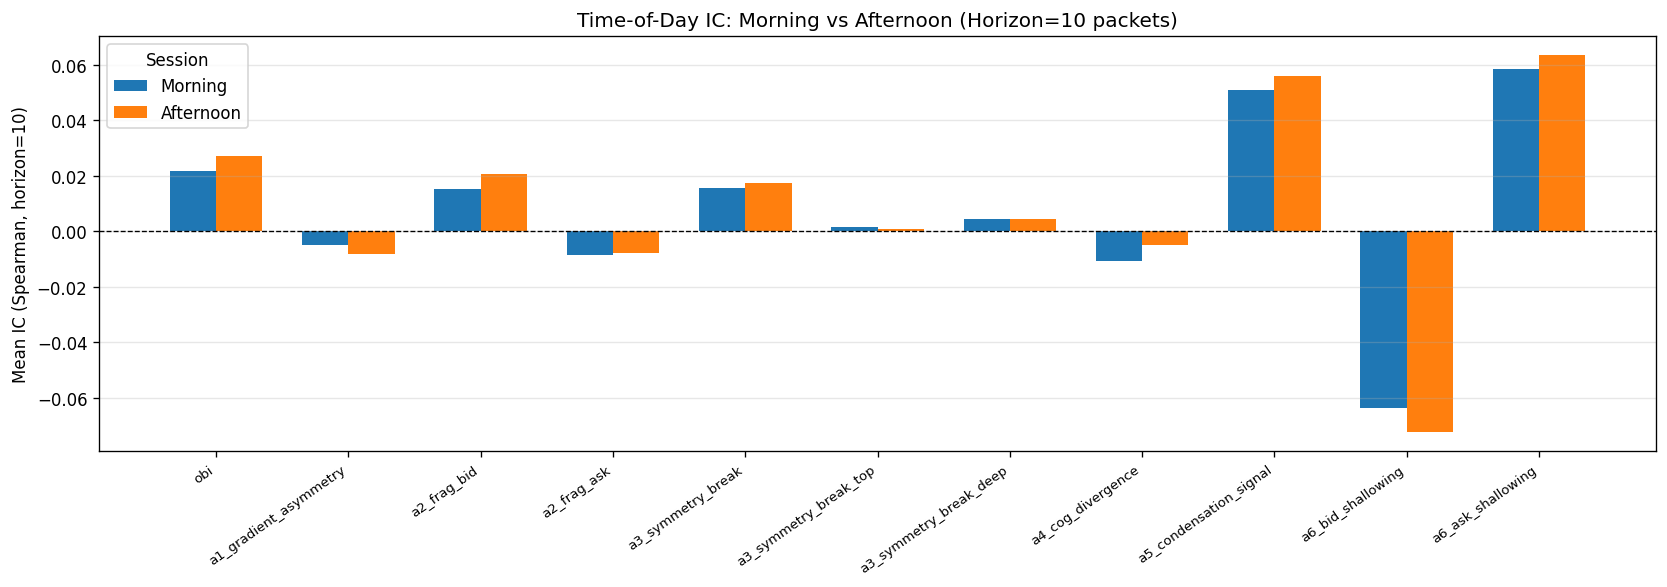

In [23]:
sessions = ["morning", "afternoon"]
x = np.arange(len(SIGNALS))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5), dpi=120)

for i, sess in enumerate(sessions):
    vals = [
        tod_summary.loc[
            (tod_summary["signal"] == sig) & (tod_summary["session"] == sess), "ic"
        ].values[0]
        if len(tod_summary.loc[
            (tod_summary["signal"] == sig) & (tod_summary["session"] == sess), "ic"
        ]) > 0
        else np.nan
        for sig in SIGNALS
    ]
    offset = (i - 0.5) * width
    ax.bar(x + offset, vals, width, label=sess.capitalize())

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(SIGNALS, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Mean IC (Spearman, horizon=10)", fontsize=10)
ax.set_title("Time-of-Day IC: Morning vs Afternoon (Horizon=10 packets)", fontsize=12)
ax.legend(title="Session", fontsize=10)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

The IC analysis above covers:
- **11 signals** (OBI + A1–A6 sub-signals)
- **4 horizons** (5, 10, 20, 50 packets)
- **4 symbols** × **~16 days** = up to 64 day×symbol IC observations per cell

Key interpretation guidelines:
- |mean_IC| > 0.02 is economically meaningful at packet frequency
- ICIR > 0.5 suggests a robust signal
- pct_positive > 0.6 indicates directional consistency across days
- Signals with consistent sign across time-of-day are more reliable